In [38]:
from scipy.cluster.vq import kmeans
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [39]:
listener_data = pd.DataFrame({
    "weekly_listening_hours":
        [9.4, 3.0, 4.6, 29.3, 27.2, 9.6, 31.9, 16.8, 8.2, 12.3, 4.7, 8.8, 32.3, 8.2, 21.8, 1.4, 5.8, 25.3, 22.7, 22.2,
         15.7, 2.2, 31.5, 25.1, 2.5, 12.3, 32.4, 4.7, 4.0, 25.9, 4.8, 3.3, 2.2, 4.4, 11.1, 12.7, 17.6, 11.5, 24.2, 17.1,
         23.9, 14.7,
         5.0, 3.1, 17.7
            , 20.3, 30.2, 5.5],
    "followed_genres_count":
        [5, 1, 3, 11, 14, 7, 11, 7, 4, 8, 1, 4, 12, 7, 12, 3, 1, 14, 11, 10, 6, 2, 12, 12, 1, 6, 14, 1, 3, 8, 3, 3, 1,
         2, 6, 5, 4, 5, 12, 5, 14, 5, 2, 3,
         7, 8, 12, 3]
})
print(listener_data.head())

   weekly_listening_hours  followed_genres_count
0                 9.40000                      5
1                 3.00000                      1
2                 4.60000                      3
3                29.30000                     11
4                27.20000                     14


In [40]:
#B
scaler = StandardScaler()
listener_data_scaled = scaler.fit_transform(listener_data)
# listener_data_scaled = listener_data

In [41]:
#G
kmeans_model = KMeans(n_clusters=3, random_state=42)
kmeans_model.fit(listener_data_scaled)
cluster_labels = kmeans_model.labels_
listener_data_scaled_df = pd.DataFrame(listener_data_scaled,
                                       columns=listener_data.columns)

   weekly_listening_hours  followed_genres_count  cluster
0                -0.50572               -0.35234        2
1                -1.15331               -1.30513        1
2                -0.99141               -0.82874        1
3                 1.50788                1.07686        0
4                 1.29539                1.79146        0
[[ 1.28122121  1.29917959]
 [-1.01726718 -1.00076859]
 [-0.06050059 -0.09825728]]


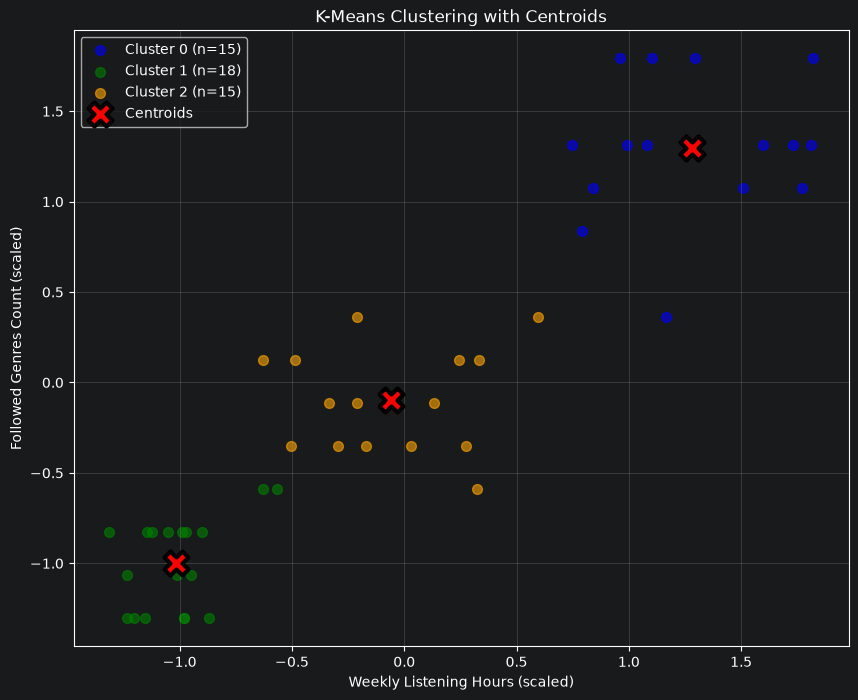

In [42]:
#D
listener_data_scaled_df['cluster'] = cluster_labels
listener_data['cluster'] = cluster_labels
print(listener_data_scaled_df.head())

centroids = kmeans_model.cluster_centers_
print(centroids)

plt.figure(figsize=(10, 8))

colors = ['blue', 'green', 'orange']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for cluster_id in range(3):
    cluster_data = listener_data_scaled_df[
        listener_data_scaled_df['cluster'] == cluster_id
        ]

    plt.scatter(
        cluster_data['weekly_listening_hours'],
        cluster_data['followed_genres_count'],
        c=colors[cluster_id],
        label=f'{cluster_names[cluster_id]} (n={len(cluster_data)})',
        alpha=0.6,
        s=50
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=300,
    c='red',
    linewidths=3,
    edgecolors='black',
    label='Centroids',
    zorder=5
)

plt.xlabel('Weekly Listening Hours (scaled)')
plt.ylabel('Followed Genres Count (scaled)')
plt.title('K-Means Clustering with Centroids')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
#H
count_of_clusters = len(listener_data['cluster'].unique())
print(f"total count: {listener_data['cluster'].count()}")
print("\n", "*" * 80)

for cluster in range(count_of_clusters):
    print("cluster:", cluster)
    print(f"count: {listener_data[listener_data_scaled_df["cluster"] == cluster]["cluster"].count()}")
    print(
        f"mean of followed_genres_count: {listener_data[listener_data_scaled_df["cluster"] == cluster]["followed_genres_count"].mean()}")
    print(
        f"mean of weekly_listening_hours: {listener_data[listener_data_scaled_df["cluster"] == cluster]["weekly_listening_hours"].mean()}")
    print("\n", "*" * 80)

total count: 48

 ********************************************************************************
cluster: 0
count: 15
mean of followed_genres_count: 11.933333333333334
mean of weekly_listening_hours: 27.059999999999995

 ********************************************************************************
cluster: 1
count: 18
mean of followed_genres_count: 2.2777777777777777
mean of weekly_listening_hours: 4.344444444444444

 ********************************************************************************
cluster: 2
count: 15
mean of followed_genres_count: 6.066666666666666
mean of weekly_listening_hours: 13.8

 ********************************************************************************


   weekly_listening_hours  followed_genres_count  cluster
0                 9.40000                      5        1
1                 3.00000                      1        1
2                 4.60000                      3        1
3                29.30000                     11        0
4                27.20000                     14        0

(Centroids):
[[24.77       10.5         0.5       ]
 [ 6.98928571  3.60714286  1.35714286]]


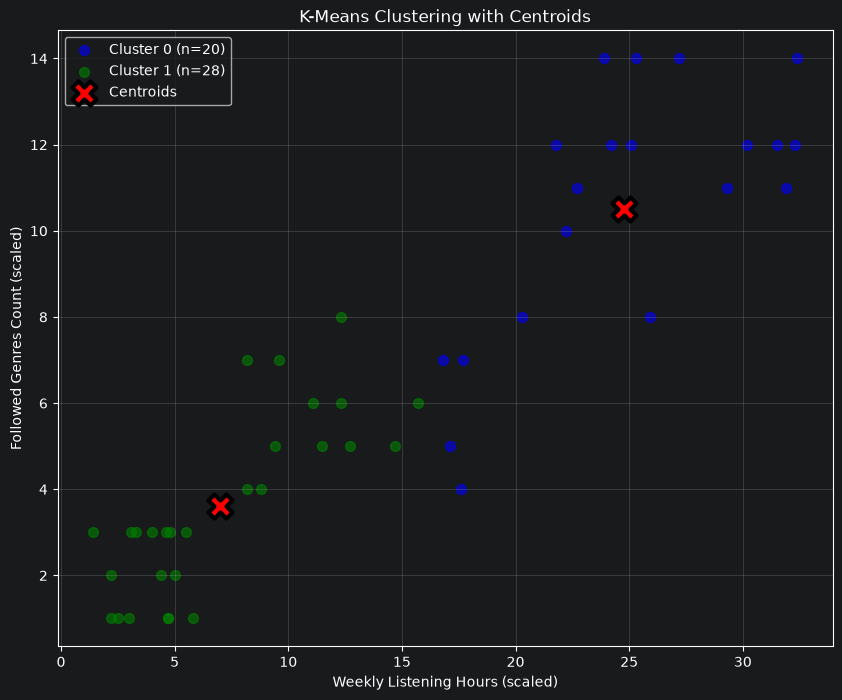

   weekly_listening_hours  followed_genres_count  cluster
0                 9.40000                      5        5
1                 3.00000                      1        1
2                 4.60000                      3        1
3                29.30000                     11        4
4                27.20000                     14        0

(Centroids):
[[2.42555556e+01 1.18888889e+01 1.11022302e-16]
 [3.82500000e+00 2.06250000e+00 1.00000000e+00]
 [1.71285714e+01 6.00000000e+00 2.85714286e-01]
 [1.15833333e+01 6.16666667e+00 1.00000000e+00]
 [3.12666667e+01 1.20000000e+01 0.00000000e+00]
 [8.65000000e+00 5.00000000e+00 1.00000000e+00]]


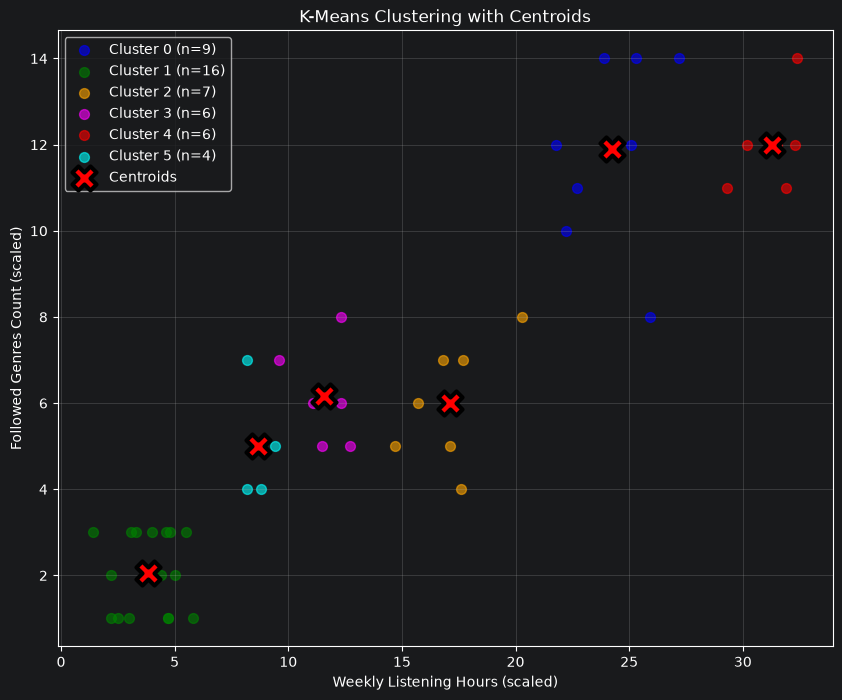

In [44]:
#H
scaler = StandardScaler()
# listener_data_scaled = scaler.fit_transform(listener_data)
listener_data_scaled = listener_data
for n_cluster in [2, 6]:
    kmeans_model = KMeans(n_clusters=n_cluster, random_state=42)
    kmeans_model.fit(listener_data_scaled)
    cluster_labels = kmeans_model.labels_
    listener_data_scaled_df = pd.DataFrame(listener_data_scaled,
                                           columns=listener_data.columns)
    listener_data_scaled_df['cluster'] = cluster_labels
    listener_data['cluster'] = cluster_labels
    print(listener_data_scaled_df.head())

    centroids = kmeans_model.cluster_centers_
    print("\n(Centroids):")
    print(centroids)

    plt.figure(figsize=(10, 8))

    colors = ['blue', 'green', 'orange', 'magenta', 'red', 'cyan', 'magenta']
    cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5', 'Cluster 6']

    for cluster_id in range(n_cluster):
        cluster_data = listener_data_scaled_df[listener_data_scaled_df['cluster'] == cluster_id]

        plt.scatter(
            cluster_data['weekly_listening_hours'],
            cluster_data['followed_genres_count'],
            c=colors[cluster_id],
            label=f'{cluster_names[cluster_id]} (n={len(cluster_data)})',
            alpha=0.6,
            s=50
        )

    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker='X',
        s=300,
        c='red',
        linewidths=3,
        edgecolors='black',
        label='Centroids',
        zorder=5
    )

    plt.xlabel('Weekly Listening Hours (scaled)')
    plt.ylabel('Followed Genres Count (scaled)')
    plt.title('K-Means Clustering with Centroids')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()